# EEG Oddball Classification

**Objective:** Optimize classification between frequent and target trials

**Two Approaches:**
1. Pooled SMOTE: Balance total frequent = total target across all subjects
2. Per-Subject SMOTE: Balance frequent = target within each subject separately

## 1. Setup

In [43]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from collections import defaultdict

from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

RESULTS_DIR = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)
RANDOM_STATE = 42

print("Setup complete.")

Setup complete.


## 2. Load Data

In [44]:
# Load EEG features
df_eeg = pd.read_csv('/kaggle/input/eeghmm/eeg.csv')
df_eeg = df_eeg[df_eeg['label'].isin([0, 1])].copy()

# Load HMM features  
df_hmm = pd.read_csv('/kaggle/input/eeghmm/hmm.csv')
df_hmm = df_hmm[df_hmm['label'].isin([0, 1])].copy()

subjects = sorted(df_eeg['subject_id'].unique())

print(f"Subjects: {subjects}")
print(f"\nEEG: {len(df_eeg)} samples, {len(df_eeg.columns)-3} features")
print(f"HMM: {len(df_hmm)} samples, {len(df_hmm.columns)-3} features")
print(f"\nClass distribution:")
print(f"  Frequent: {(df_eeg['label']==0).sum()}")
print(f"  Target:   {(df_eeg['label']==1).sum()}")
print(f"  Ratio:    {(df_eeg['label']==0).sum()/(df_eeg['label']==1).sum():.1f}:1")

Subjects: ['sub-01', 'sub-02', 'sub-03', 'sub-05']

EEG: 847 samples, 4 features
HMM: 847 samples, 6 features

Class distribution:
  Frequent: 742
  Target:   105
  Ratio:    7.1:1


---
# APPROACH 1: Pooled SMOTE
Balance total frequent = total target across all subjects

## 3. Approach 1: Prepare Data with Pooled SMOTE

In [45]:
def prepare_pooled_smote(df):
    X = df.drop(columns=['label', 'subject_id', 'epoch_idx'])
    y = df['label']
    
    print(f"Before SMOTE: Frequent={(y==0).sum()}, Target={(y==1).sum()}")
    
    smote = SMOTE(random_state=RANDOM_STATE)
    X_balanced, y_balanced = smote.fit_resample(X, y)
    
    print(f"After SMOTE:  Frequent={(y_balanced==0).sum()}, Target={(y_balanced==1).sum()}")
    print(f"Total: {len(X_balanced)} samples (50/50 balanced)")
    
    return X_balanced, y_balanced

# Prepare both feature sets
print("\nEEG Features:")
X_eeg_p1, y_eeg_p1 = prepare_pooled_smote(df_eeg)

print("\nHMM Features:")
X_hmm_p1, y_hmm_p1 = prepare_pooled_smote(df_hmm)


EEG Features:
Before SMOTE: Frequent=742, Target=105
After SMOTE:  Frequent=742, Target=742
Total: 1484 samples (50/50 balanced)

HMM Features:
Before SMOTE: Frequent=742, Target=105
After SMOTE:  Frequent=742, Target=742
Total: 1484 samples (50/50 balanced)


## 4. Approach 1: Hyperparameter Optimization

In [46]:
def optimize_and_train(X, y, model_type, param_grid):
    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
    )
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Grid search for optimal hyperparameters
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    grid_search = GridSearchCV(
        model_type, param_grid, cv=cv, scoring='f1', n_jobs=-1, verbose=0
    )
    grid_search.fit(X_train_scaled, y_train)
    
    # Best model
    best_model = grid_search.best_estimator_
    
    # Predictions
    y_pred = best_model.predict(X_test_scaled)
    y_pred_proba = best_model.predict_proba(X_test_scaled)[:, 1]
    
    return {
        'best_params': grid_search.best_params_,
        'best_score': grid_search.best_score_,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_pred_proba)
    }

# Define search spaces
param_grids = {
    'SVM': {
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto', 0.01],
        'kernel': ['rbf', 'linear']
    },
    'RandomForest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5]
    },
    'LightGBM': {
        'n_estimators': [100, 200],
        'learning_rate': [0.01, 0.1],
        'num_leaves': [31, 50],
        'max_depth': [-1, 10, 20]
    },
    'LogisticRegression': {
        'C': [0.1, 1, 10],
        'solver': ['liblinear', 'lbfgs'],
        'penalty': ['l2']
    },
    'KNN': {
        'n_neighbors': [3, 5, 7, 9],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    },
    'NeuralNetwork': {
        'hidden_layer_sizes': [(64, 32), (100,), (128, 64)],
        'alpha': [0.0001, 0.001, 0.01],
        'learning_rate_init': [0.001, 0.01]
    }
}

# print("Hyperparameter search spaces defined.")
# print(f"\nSVM: {len(param_grids['SVM']['C']) * len(param_grids['SVM']['gamma']) * len(param_grids['SVM']['kernel'])} combinations")
# print(f"RF:  {len(param_grids['RandomForest']['n_estimators']) * len(param_grids['RandomForest']['max_depth']) * len(param_grids['RandomForest']['min_samples_split'])} combinations")
# print(f"NN:  {len(param_grids['NeuralNetwork']['hidden_layer_sizes']) * len(param_grids['NeuralNetwork']['alpha']) * len(param_grids['NeuralNetwork']['learning_rate_init'])} combinations")

## 5. Approach 1: Train and Optimize Models

In [47]:
# Train on EEG features
print("Training on EEG features...\n")
results_eeg_p1 = {}

print("SVM:")
results_eeg_p1['SVM'] = optimize_and_train(
    X_eeg_p1, y_eeg_p1, 
    SVC(probability=True, random_state=RANDOM_STATE, class_weight='balanced'),
    param_grids['SVM']
)
print(f"  Best params: {results_eeg_p1['SVM']['best_params']}")
print(f"  F1: {results_eeg_p1['SVM']['f1']:.3f}, Accuracy: {results_eeg_p1['SVM']['accuracy']:.3f}\n")

print("Random Forest:")
results_eeg_p1['RandomForest'] = optimize_and_train(
    X_eeg_p1, y_eeg_p1,
    RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced'),
    param_grids['RandomForest']
)
print(f"  Best params: {results_eeg_p1['RandomForest']['best_params']}")
print(f"  F1: {results_eeg_p1['RandomForest']['f1']:.3f}, Accuracy: {results_eeg_p1['RandomForest']['accuracy']:.3f}\n")

print("LightGBM:")
results_eeg_p1['LightGBM'] = optimize_and_train(
    X_eeg_p1, y_eeg_p1,
    LGBMClassifier(random_state=RANDOM_STATE, class_weight='balanced', verbose=-1),
    param_grids['LightGBM']
)
print(f"  Best params: {results_eeg_p1['LightGBM']['best_params']}")
print(f"  F1: {results_eeg_p1['LightGBM']['f1']:.3f}, Accuracy: {results_eeg_p1['LightGBM']['accuracy']:.3f}\n")

print("Logistic Regression:")
results_eeg_p1['LogisticRegression'] = optimize_and_train(
    X_eeg_p1, y_eeg_p1,
    LogisticRegression(random_state=RANDOM_STATE, class_weight='balanced', max_iter=1000),
    param_grids['LogisticRegression']
)
print(f"  Best params: {results_eeg_p1['LogisticRegression']['best_params']}")
print(f"  F1: {results_eeg_p1['LogisticRegression']['f1']:.3f}, Accuracy: {results_eeg_p1['LogisticRegression']['accuracy']:.3f}\n")

print("KNN:")
results_eeg_p1['KNN'] = optimize_and_train(
    X_eeg_p1, y_eeg_p1,
    KNeighborsClassifier(), # KNN không có random_state và class_weight
    param_grids['KNN']
)
print(f"  Best params: {results_eeg_p1['KNN']['best_params']}")
print(f"  F1: {results_eeg_p1['KNN']['f1']:.3f}, Accuracy: {results_eeg_p1['KNN']['accuracy']:.3f}\n")

print("Neural Network:")
results_eeg_p1['NeuralNetwork'] = optimize_and_train(
    X_eeg_p1, y_eeg_p1,
    MLPClassifier(random_state=RANDOM_STATE, max_iter=2000, early_stopping=True),
    param_grids['NeuralNetwork']
)
print(f"  Best params: {results_eeg_p1['NeuralNetwork']['best_params']}")
print(f"  F1: {results_eeg_p1['NeuralNetwork']['f1']:.3f}, Accuracy: {results_eeg_p1['NeuralNetwork']['accuracy']:.3f}")



Training on EEG features...

SVM:
  Best params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
  F1: 0.742, Accuracy: 0.724

Random Forest:
  Best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}
  F1: 0.799, Accuracy: 0.791

LightGBM:
  Best params: {'learning_rate': 0.1, 'max_depth': -1, 'n_estimators': 200, 'num_leaves': 50}
  F1: 0.812, Accuracy: 0.801

Logistic Regression:
  Best params: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
  F1: 0.690, Accuracy: 0.673

KNN:
  Best params: {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'distance'}
  F1: 0.764, Accuracy: 0.734

Neural Network:
  Best params: {'alpha': 0.001, 'hidden_layer_sizes': (64, 32), 'learning_rate_init': 0.01}
  F1: 0.738, Accuracy: 0.714


In [48]:
# Train on HMM features
print("\nTraining on HMM features...\n")
results_hmm_p1 = {}

print("SVM:")
results_hmm_p1['SVM'] = optimize_and_train(
    X_hmm_p1, y_hmm_p1,
    SVC(probability=True, random_state=RANDOM_STATE, class_weight='balanced'),
    param_grids['SVM']
)
print(f"  Best params: {results_hmm_p1['SVM']['best_params']}")
print(f"  F1: {results_hmm_p1['SVM']['f1']:.3f}, Accuracy: {results_hmm_p1['SVM']['accuracy']:.3f}\n")

print("Random Forest:")
results_hmm_p1['RandomForest'] = optimize_and_train(
    X_hmm_p1, y_hmm_p1,
    RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced'),
    param_grids['RandomForest']
)
print(f"  Best params: {results_hmm_p1['RandomForest']['best_params']}")
print(f"  F1: {results_hmm_p1['RandomForest']['f1']:.3f}, Accuracy: {results_hmm_p1['RandomForest']['accuracy']:.3f}\n")

print("LightGBM:")
results_hmm_p1['LightGBM'] = optimize_and_train(
    X_hmm_p1, y_hmm_p1,
    LGBMClassifier(random_state=RANDOM_STATE, class_weight='balanced', verbose=-1),
    param_grids['LightGBM']
)
print(f"  Best params: {results_hmm_p1['LightGBM']['best_params']}")
print(f"  F1: {results_hmm_p1['LightGBM']['f1']:.3f}, Accuracy: {results_hmm_p1['LightGBM']['accuracy']:.3f}\n")

print("Logistic Regression:")
results_hmm_p1['LogisticRegression'] = optimize_and_train(
    X_hmm_p1, y_hmm_p1,
    LogisticRegression(random_state=RANDOM_STATE, class_weight='balanced', max_iter=1000),
    param_grids['LogisticRegression']
)
print(f"  Best params: {results_hmm_p1['LogisticRegression']['best_params']}")
print(f"  F1: {results_hmm_p1['LogisticRegression']['f1']:.3f}, Accuracy: {results_hmm_p1['LogisticRegression']['accuracy']:.3f}\n")

print("KNN:")
results_hmm_p1['KNN'] = optimize_and_train(
    X_hmm_p1, y_hmm_p1,
    KNeighborsClassifier(), # KNN không có tham số random_state
    param_grids['KNN']
)
print(f"  Best params: {results_hmm_p1['KNN']['best_params']}")
print(f"  F1: {results_hmm_p1['KNN']['f1']:.3f}, Accuracy: {results_hmm_p1['KNN']['accuracy']:.3f}\n")


print("Neural Network:")
results_hmm_p1['NeuralNetwork'] = optimize_and_train(
    X_hmm_p1, y_hmm_p1,
    MLPClassifier(random_state=RANDOM_STATE, max_iter=2000, early_stopping=True),
    param_grids['NeuralNetwork']
)
print(f"  Best params: {results_hmm_p1['NeuralNetwork']['best_params']}")
print(f"  F1: {results_hmm_p1['NeuralNetwork']['f1']:.3f}, Accuracy: {results_hmm_p1['NeuralNetwork']['accuracy']:.3f}")


Training on HMM features...

SVM:
  Best params: {'C': 100, 'gamma': 'auto', 'kernel': 'rbf'}
  F1: 0.837, Accuracy: 0.822

Random Forest:
  Best params: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 300}
  F1: 0.884, Accuracy: 0.882

LightGBM:
  Best params: {'learning_rate': 0.1, 'max_depth': 20, 'n_estimators': 200, 'num_leaves': 31}
  F1: 0.880, Accuracy: 0.879

Logistic Regression:
  Best params: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
  F1: 0.545, Accuracy: 0.572

KNN:
  Best params: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
  F1: 0.855, Accuracy: 0.835
Neural Network:
  Best params: {'alpha': 0.01, 'hidden_layer_sizes': (64, 32), 'learning_rate_init': 0.01}
  F1: 0.731, Accuracy: 0.737


## 6. Approach 1: Results Summary

In [49]:
print("\n" + "="*80)
print("APPROACH 1 RESULTS (Pooled SMOTE)")
print("="*80)

# Find best models
best_eeg_p1 = max(results_eeg_p1.items(), key=lambda x: x[1]['f1'])
best_hmm_p1 = max(results_hmm_p1.items(), key=lambda x: x[1]['f1'])

print(f"\nBest EEG Model: {best_eeg_p1[0]}")
print(f"  F1:        {best_eeg_p1[1]['f1']:.4f}")
print(f"  Accuracy:  {best_eeg_p1[1]['accuracy']:.4f}")
print(f"  Precision: {best_eeg_p1[1]['precision']:.4f}")
print(f"  Recall:    {best_eeg_p1[1]['recall']:.4f}")
print(f"  ROC-AUC:   {best_eeg_p1[1]['roc_auc']:.4f}")

print(f"\nBest HMM Model: {best_hmm_p1[0]}")
print(f"  F1:        {best_hmm_p1[1]['f1']:.4f}")
print(f"  Accuracy:  {best_hmm_p1[1]['accuracy']:.4f}")
print(f"  Precision: {best_hmm_p1[1]['precision']:.4f}")
print(f"  Recall:    {best_hmm_p1[1]['recall']:.4f}")
print(f"  ROC-AUC:   {best_hmm_p1[1]['roc_auc']:.4f}")

improvement_p1 = ((best_hmm_p1[1]['f1'] - best_eeg_p1[1]['f1']) / best_eeg_p1[1]['f1']) * 100
print(f"\nHMM Improvement: +{improvement_p1:.2f}%")
print("="*80)


APPROACH 1 RESULTS (Pooled SMOTE)

Best EEG Model: LightGBM
  F1:        0.8115
  Accuracy:  0.8013
  Precision: 0.7697
  Recall:    0.8581
  ROC-AUC:   0.8811

Best HMM Model: RandomForest
  F1:        0.8837
  Accuracy:  0.8822
  Precision: 0.8693
  Recall:    0.8986
  ROC-AUC:   0.9495

HMM Improvement: +8.90%


---
# APPROACH 2: Per-Subject SMOTE
Balance frequent = target within each subject separately

## 7. Approach 2: Prepare Data with Per-Subject SMOTE

In [50]:
def prepare_per_subject_smote(df, subjects):
    X_list = []
    y_list = []
    
    print("Balancing each subject separately:")
    for subject in subjects:
        df_subj = df[df['subject_id'] == subject]
        X_subj = df_subj.drop(columns=['label', 'subject_id', 'epoch_idx'])
        y_subj = df_subj['label']
        
        freq_before = (y_subj == 0).sum()
        targ_before = (y_subj == 1).sum()
        
        # SMOTE requires at least k_neighbors+1 samples in minority class
        # Adjust k_neighbors based on minority class size
        min_samples = min(freq_before, targ_before)
        
        if min_samples < 2:
            print(f"  {subject}: SKIPPED (only {targ_before} target, need at least 2)")
            continue
        
        # k_neighbors must be < min_samples
        k_neighbors = min(5, min_samples - 1)
        
        # SMOTE within subject
        smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=k_neighbors)
        X_balanced, y_balanced = smote.fit_resample(X_subj, y_subj)
        
        X_list.append(X_balanced)
        y_list.append(y_balanced)
        
        freq_after = (y_balanced == 0).sum()
        targ_after = (y_balanced == 1).sum()
        
        print(f"  {subject}: {freq_before:3d}/{targ_before:2d} → {freq_after:3d}/{targ_after:3d} (k={k_neighbors})")
    
    X_combined = pd.concat([pd.DataFrame(x) for x in X_list], ignore_index=True)
    y_combined = pd.concat([pd.Series(y) for y in y_list], ignore_index=True)
    
    print(f"\nTotal: {len(X_combined)} samples")
    print(f"  Frequent: {(y_combined==0).sum()}")
    print(f"  Target:   {(y_combined==1).sum()}")
    
    return X_combined.values, y_combined.values

# Prepare both feature sets
print("\nEEG Features:")
X_eeg_p2, y_eeg_p2 = prepare_per_subject_smote(df_eeg, subjects)

print("\n" + "-"*80)
print("\nHMM Features:")
X_hmm_p2, y_hmm_p2 = prepare_per_subject_smote(df_hmm, subjects)


EEG Features:
Balancing each subject separately:
  sub-01:  67/ 5 →  67/ 67 (k=4)
  sub-02:  32/11 →  32/ 32 (k=5)
  sub-03: 295/77 → 295/295 (k=5)
  sub-05: 348/12 → 348/348 (k=5)

Total: 1484 samples
  Frequent: 742
  Target:   742

--------------------------------------------------------------------------------

HMM Features:
Balancing each subject separately:
  sub-01:  67/ 5 →  67/ 67 (k=4)
  sub-02:  32/11 →  32/ 32 (k=5)
  sub-03: 295/77 → 295/295 (k=5)
  sub-05: 348/12 → 348/348 (k=5)

Total: 1484 samples
  Frequent: 742
  Target:   742


## 8. Approach 2: Train and Optimize Models

In [51]:
# Train on EEG features
print("\nTraining on EEG features...\n")
results_eeg_p2 = {}

print("SVM:")
results_eeg_p2['SVM'] = optimize_and_train(
    X_eeg_p2, y_eeg_p2,
    SVC(probability=True, random_state=RANDOM_STATE, class_weight='balanced'),
    param_grids['SVM']
)
print(f"  Best params: {results_eeg_p2['SVM']['best_params']}")
print(f"  F1: {results_eeg_p2['SVM']['f1']:.3f}, Accuracy: {results_eeg_p2['SVM']['accuracy']:.3f}\n")

print("Random Forest:")
results_eeg_p2['RandomForest'] = optimize_and_train(
    X_eeg_p2, y_eeg_p2,
    RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced'),
    param_grids['RandomForest']
)
print(f"  Best params: {results_eeg_p2['RandomForest']['best_params']}")
print(f"  F1: {results_eeg_p2['RandomForest']['f1']:.3f}, Accuracy: {results_eeg_p2['RandomForest']['accuracy']:.3f}\n")

print("LightGBM:")
results_eeg_p2['LightGBM'] = optimize_and_train(
    X_eeg_p2, y_eeg_p2,
    LGBMClassifier(random_state=RANDOM_STATE, class_weight='balanced', verbose=-1),
    param_grids['LightGBM']
)
print(f"  Best params: {results_eeg_p2['LightGBM']['best_params']}")
print(f"  F1: {results_eeg_p2['LightGBM']['f1']:.3f}, Accuracy: {results_eeg_p2['LightGBM']['accuracy']:.3f}\n")

print("Logistic Regression:")
results_eeg_p2['LogisticRegression'] = optimize_and_train(
    X_eeg_p2, y_eeg_p2,
    LogisticRegression(random_state=RANDOM_STATE, class_weight='balanced', max_iter=1000),
    param_grids['LogisticRegression']
)
print(f"  Best params: {results_eeg_p2['LogisticRegression']['best_params']}")
print(f"  F1: {results_eeg_p2['LogisticRegression']['f1']:.3f}, Accuracy: {results_eeg_p2['LogisticRegression']['accuracy']:.3f}\n")

print("KNN:")
results_eeg_p2['KNN'] = optimize_and_train(
    X_eeg_p2, y_eeg_p2,
    KNeighborsClassifier(),
    param_grids['KNN']
)
print(f"  Best params: {results_eeg_p2['KNN']['best_params']}")
print(f"  F1: {results_eeg_p2['KNN']['f1']:.3f}, Accuracy: {results_eeg_p2['KNN']['accuracy']:.3f}\n")

print("Neural Network:")
results_eeg_p2['NeuralNetwork'] = optimize_and_train(
    X_eeg_p2, y_eeg_p2,
    MLPClassifier(random_state=RANDOM_STATE, max_iter=2000, early_stopping=True),
    param_grids['NeuralNetwork']
)
print(f"  Best params: {results_eeg_p2['NeuralNetwork']['best_params']}")
print(f"  F1: {results_eeg_p2['NeuralNetwork']['f1']:.3f}, Accuracy: {results_eeg_p2['NeuralNetwork']['accuracy']:.3f}")


Training on EEG features...

SVM:
  Best params: {'C': 100, 'gamma': 'auto', 'kernel': 'rbf'}
  F1: 0.816, Accuracy: 0.798

Random Forest:
  Best params: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 300}
  F1: 0.814, Accuracy: 0.808

LightGBM:
  Best params: {'learning_rate': 0.1, 'max_depth': -1, 'n_estimators': 200, 'num_leaves': 31}
  F1: 0.815, Accuracy: 0.805

Logistic Regression:
  Best params: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
  F1: 0.756, Accuracy: 0.754

KNN:
  Best params: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
  F1: 0.802, Accuracy: 0.785

Neural Network:
  Best params: {'alpha': 0.0001, 'hidden_layer_sizes': (64, 32), 'learning_rate_init': 0.01}
  F1: 0.796, Accuracy: 0.774


In [52]:
# Train on HMM features
print("\nTraining on HMM features...\n")
results_hmm_p2 = {}

print("SVM:")
results_hmm_p2['SVM'] = optimize_and_train(
    X_hmm_p2, y_hmm_p2,
    SVC(probability=True, random_state=RANDOM_STATE, class_weight='balanced'),
    param_grids['SVM']
)
print(f"  Best params: {results_hmm_p2['SVM']['best_params']}")
print(f"  F1: {results_hmm_p2['SVM']['f1']:.3f}, Accuracy: {results_hmm_p2['SVM']['accuracy']:.3f}\n")

print("Random Forest:")
results_hmm_p2['RandomForest'] = optimize_and_train(
    X_hmm_p2, y_hmm_p2,
    RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced'),
    param_grids['RandomForest']
)
print(f"  Best params: {results_hmm_p2['RandomForest']['best_params']}")
print(f"  F1: {results_hmm_p2['RandomForest']['f1']:.3f}, Accuracy: {results_hmm_p2['RandomForest']['accuracy']:.3f}\n")

print("LightGBM:")
results_hmm_p2['LightGBM'] = optimize_and_train(
    X_hmm_p2, y_hmm_p2,
    LGBMClassifier(random_state=RANDOM_STATE, class_weight='balanced', verbose=-1),
    param_grids['LightGBM']
)
print(f"  Best params: {results_hmm_p2['LightGBM']['best_params']}")
print(f"  F1: {results_hmm_p2['LightGBM']['f1']:.3f}, Accuracy: {results_hmm_p2['LightGBM']['accuracy']:.3f}\n")

print("Logistic Regression:")
results_hmm_p2['LogisticRegression'] = optimize_and_train(
    X_hmm_p2, y_hmm_p2,
    LogisticRegression(random_state=RANDOM_STATE, class_weight='balanced', max_iter=1000),
    param_grids['LogisticRegression']
)
print(f"  Best params: {results_hmm_p2['LogisticRegression']['best_params']}")
print(f"  F1: {results_hmm_p2['LogisticRegression']['f1']:.3f}, Accuracy: {results_hmm_p2['LogisticRegression']['accuracy']:.3f}\n")

print("KNN:")
results_hmm_p2['KNN'] = optimize_and_train(
    X_hmm_p2, y_hmm_p2,
    KNeighborsClassifier(),
    param_grids['KNN']
)
print(f"  Best params: {results_hmm_p2['KNN']['best_params']}")
print(f"  F1: {results_hmm_p2['KNN']['f1']:.3f}, Accuracy: {results_hmm_p2['KNN']['accuracy']:.3f}")

print("Neural Network:")
results_hmm_p2['NeuralNetwork'] = optimize_and_train(
    X_hmm_p2, y_hmm_p2,
    MLPClassifier(random_state=RANDOM_STATE, max_iter=2000, early_stopping=True),
    param_grids['NeuralNetwork']
)
print(f"  Best params: {results_hmm_p2['NeuralNetwork']['best_params']}")
print(f"  F1: {results_hmm_p2['NeuralNetwork']['f1']:.3f}, Accuracy: {results_hmm_p2['NeuralNetwork']['accuracy']:.3f}")


Training on HMM features...

SVM:
  Best params: {'C': 100, 'gamma': 'auto', 'kernel': 'rbf'}
  F1: 0.810, Accuracy: 0.795

Random Forest:
  Best params: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 300}
  F1: 0.867, Accuracy: 0.869

LightGBM:
  Best params: {'learning_rate': 0.1, 'max_depth': -1, 'n_estimators': 200, 'num_leaves': 31}
  F1: 0.886, Accuracy: 0.886

Logistic Regression:
  Best params: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
  F1: 0.583, Accuracy: 0.576

KNN:
  Best params: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
  F1: 0.820, Accuracy: 0.795
Neural Network:
  Best params: {'alpha': 0.0001, 'hidden_layer_sizes': (64, 32), 'learning_rate_init': 0.01}
  F1: 0.767, Accuracy: 0.771


## 9. Approach 2: Results Summary

In [53]:
print("\n" + "="*80)
print("APPROACH 2 RESULTS (Per-Subject SMOTE)")
print("="*80)

# Find best models
best_eeg_p2 = max(results_eeg_p2.items(), key=lambda x: x[1]['f1'])
best_hmm_p2 = max(results_hmm_p2.items(), key=lambda x: x[1]['f1'])

print(f"\nBest EEG Model: {best_eeg_p2[0]}")
print(f"  F1:        {best_eeg_p2[1]['f1']:.4f}")
print(f"  Accuracy:  {best_eeg_p2[1]['accuracy']:.4f}")
print(f"  Precision: {best_eeg_p2[1]['precision']:.4f}")
print(f"  Recall:    {best_eeg_p2[1]['recall']:.4f}")
print(f"  ROC-AUC:   {best_eeg_p2[1]['roc_auc']:.4f}")

print(f"\nBest HMM Model: {best_hmm_p2[0]}")
print(f"  F1:        {best_hmm_p2[1]['f1']:.4f}")
print(f"  Accuracy:  {best_hmm_p2[1]['accuracy']:.4f}")
print(f"  Precision: {best_hmm_p2[1]['precision']:.4f}")
print(f"  Recall:    {best_hmm_p2[1]['recall']:.4f}")
print(f"  ROC-AUC:   {best_hmm_p2[1]['roc_auc']:.4f}")

improvement_p2 = ((best_hmm_p2[1]['f1'] - best_eeg_p2[1]['f1']) / best_eeg_p2[1]['f1']) * 100
print(f"\nHMM Improvement: +{improvement_p2:.2f}%")
print("="*80)


APPROACH 2 RESULTS (Per-Subject SMOTE)

Best EEG Model: SVM
  F1:        0.8160
  Accuracy:  0.7980
  Precision: 0.7472
  Recall:    0.8986
  ROC-AUC:   0.8177

Best HMM Model: LightGBM
  F1:        0.8859
  Accuracy:  0.8855
  Precision: 0.8800
  Recall:    0.8919
  ROC-AUC:   0.9300

HMM Improvement: +8.57%


---
# COMPARISON

## 10. Compare Both Approaches

In [54]:
print("\n" + "="*80)
print("FINAL COMPARISON")
print("="*80)

comparison = pd.DataFrame([
    {
        'Approach': 'Pooled SMOTE',
        'Features': 'EEG',
        'Best Model': best_eeg_p1[0],
        'F1': f"{best_eeg_p1[1]['f1']:.4f}",
        'Accuracy': f"{best_eeg_p1[1]['accuracy']:.4f}"
    },
    {
        'Approach': 'Pooled SMOTE',
        'Features': 'HMM',
        'Best Model': best_hmm_p1[0],
        'F1': f"{best_hmm_p1[1]['f1']:.4f}",
        'Accuracy': f"{best_hmm_p1[1]['accuracy']:.4f}"
    },
    {
        'Approach': 'Per-Subject SMOTE',
        'Features': 'EEG',
        'Best Model': best_eeg_p2[0],
        'F1': f"{best_eeg_p2[1]['f1']:.4f}",
        'Accuracy': f"{best_eeg_p2[1]['accuracy']:.4f}"
    },
    {
        'Approach': 'Per-Subject SMOTE',
        'Features': 'HMM',
        'Best Model': best_hmm_p2[0],
        'F1': f"{best_hmm_p2[1]['f1']:.4f}",
        'Accuracy': f"{best_hmm_p2[1]['accuracy']:.4f}"
    }
])

print("\n" + comparison.to_string(index=False))

print(f"\n\nHMM Improvement:")
print(f"  Pooled SMOTE:      +{improvement_p1:.2f}%")
print(f"  Per-Subject SMOTE: +{improvement_p2:.2f}%")

# Save
comparison.to_csv(os.path.join(RESULTS_DIR, 'comparison.csv'), index=False)
print(f"\nResults saved to {RESULTS_DIR}/comparison.csv")
print("="*80)


FINAL COMPARISON

         Approach Features   Best Model     F1 Accuracy
     Pooled SMOTE      EEG     LightGBM 0.8115   0.8013
     Pooled SMOTE      HMM RandomForest 0.8837   0.8822
Per-Subject SMOTE      EEG          SVM 0.8160   0.7980
Per-Subject SMOTE      HMM     LightGBM 0.8859   0.8855


HMM Improvement:
  Pooled SMOTE:      +8.90%
  Per-Subject SMOTE: +8.57%

Results saved to results/comparison.csv


## 11. Visualization

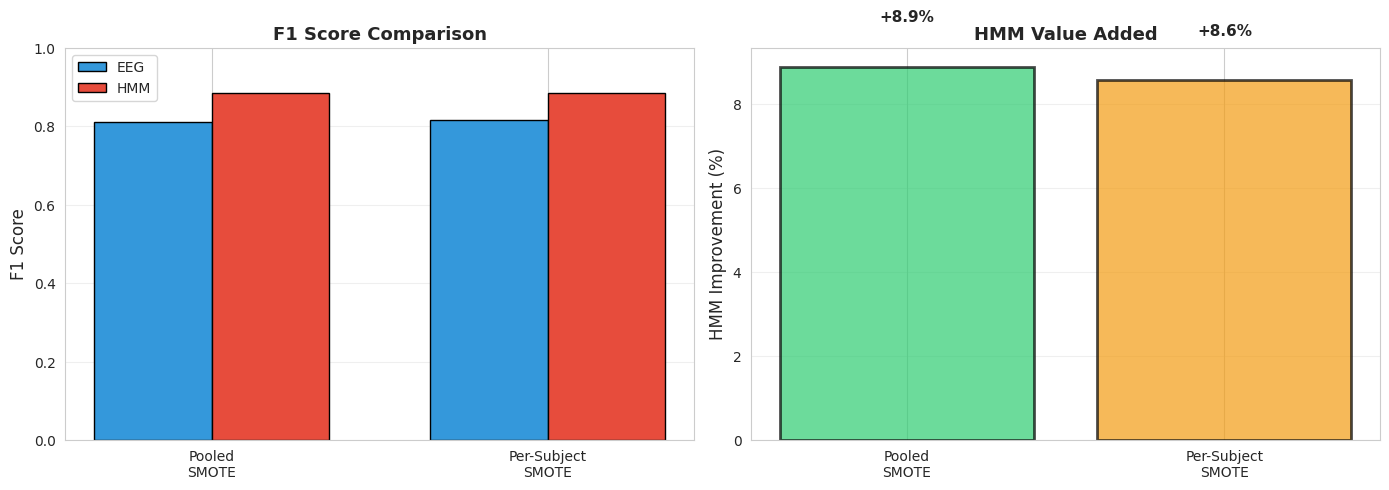

Figure saved to results/comparison.png


In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: F1 Score Comparison
approaches = ['Pooled\nSMOTE', 'Per-Subject\nSMOTE']
eeg_f1 = [best_eeg_p1[1]['f1'], best_eeg_p2[1]['f1']]
hmm_f1 = [best_hmm_p1[1]['f1'], best_hmm_p2[1]['f1']]

x = np.arange(len(approaches))
width = 0.35

axes[0].bar(x - width/2, eeg_f1, width, label='EEG', color='#3498db', edgecolor='black')
axes[0].bar(x + width/2, hmm_f1, width, label='HMM', color='#e74c3c', edgecolor='black')
axes[0].set_ylabel('F1 Score', fontsize=12)
axes[0].set_title('F1 Score Comparison', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(approaches)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim(0, 1.0)

# Plot 2: HMM Improvement
improvements = [improvement_p1, improvement_p2]
colors = ['#2ecc71', '#f39c12']

bars = axes[1].bar(approaches, improvements, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
axes[1].set_ylabel('HMM Improvement (%)', fontsize=12)
axes[1].set_title('HMM Value Added', fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

for bar, val in zip(bars, improvements):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 1,
                f'+{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"Figure saved to {RESULTS_DIR}/comparison.png")